In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.markers import MarkerStyle
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster import hierarchy
import rasterio as rir
import squarify 
from pypalettes import load_cmap
from highlight_text import fig_text
from pyrolite.util.time import Timescale
from Bio import Phylo 
from io import StringIO



import os
import zipfile
import tempfile
import requests

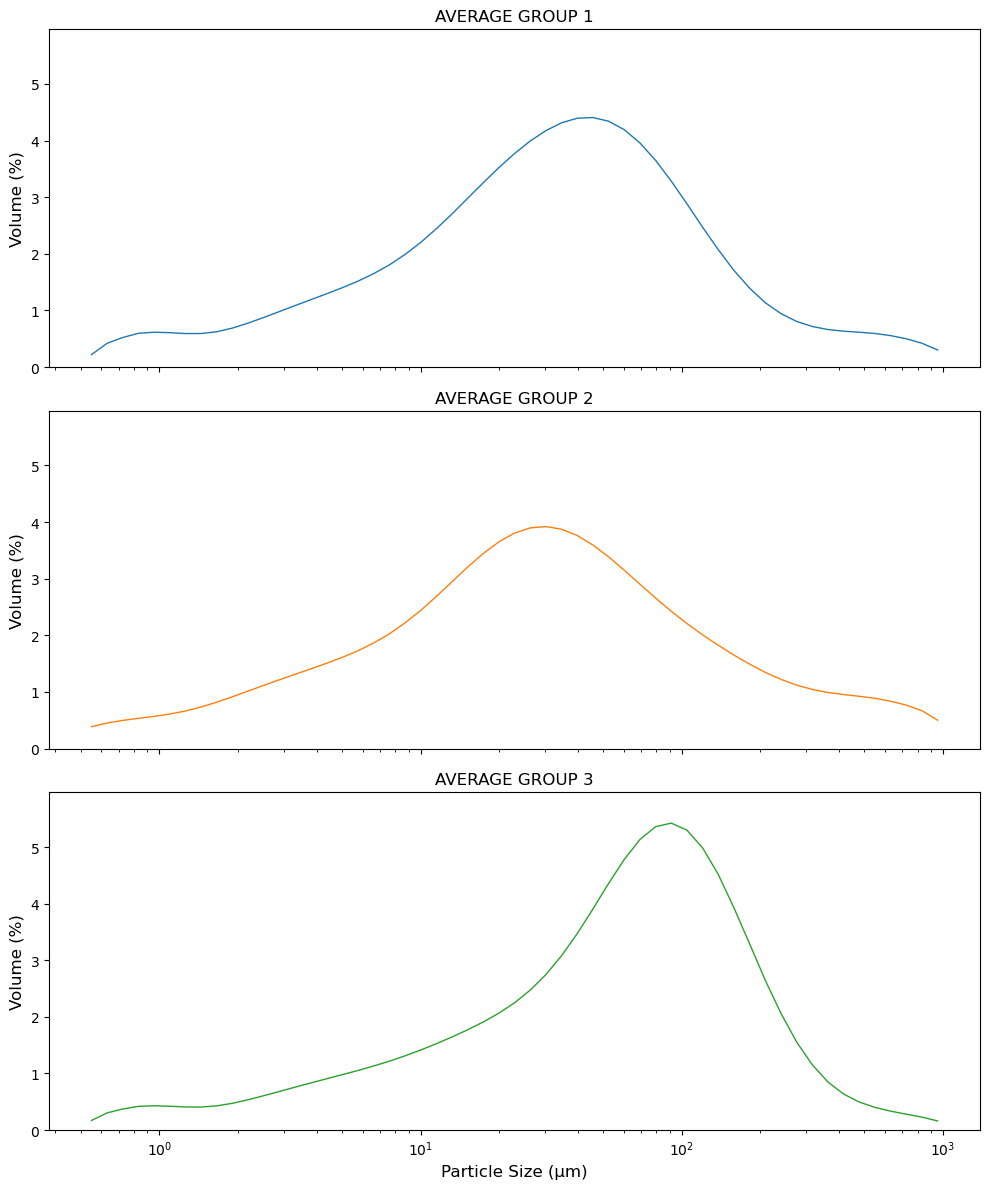

In [ ]:
# Load the file
file_name = "Malvern Data/2026_SedStrat_MalvernData.xlsx"
df = pd.read_excel(file_name)

# Extract bins and valid columns
bin_sizes_row = df.iloc[0]
distribution_cols = df.iloc[:, 58:113]

size_bins = []
valid_cols = []
for col in distribution_cols:
    val = bin_sizes_row[col]
    if pd.notna(val) and isinstance(val, (int, float)):
        size_bins.append(float(val))
        valid_cols.append(col)

# Filter average rows
avg_rows = df[df['Sample Name'].astype(str).str.contains('AVERAGE', case=False, na=False)].copy()

# Determine global max volume for consistent y-axes
max_vol = 0
plot_data = []
for index, row in avg_rows.iterrows():
    sample_name = row['Sample Name']
    volumes = pd.to_numeric(row[valid_cols], errors='coerce').fillna(0).values
    max_vol = max(max_vol, volumes.max())
    plot_data.append((sample_name, volumes))

# Create subplots
fig, axes = plt.subplots(nrows=len(plot_data), ncols=1, figsize=(10, 12), sharex=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for i, (sample_name, volumes) in enumerate(plot_data):
    ax = axes[i]
    ax.plot(size_bins, volumes, marker='', color=colors[i % len(colors)])
    ax.set_title(sample_name)
    ax.set_ylabel('Volume (%)')
    ax.set_ylim(0, max_vol * 1.1) 
    # Grid lines removed!

# X-axis formatting on the bottom subplot
axes[-1].set_xscale('log')
axes[-1].set_xlabel('Particle Size (µm)')

plt.tight_layout()
plt.savefig('grain_size_subplots_nogrid.svg', dpi=300)
plt.show()